# AgentLens 2 — SVM Training

Train an SVM to predict the tool from the prompt, compare it to the LLM
baseline, and produce the confusion matrix. Input is just `cyber_logs.csv`
(from Notebook 1) — no SSH / Ollama / CrewAI.

In [1]:
import os
import pandas as pd

# find the dataset whether this notebook sits beside the CSV or in the repo
for p in ["cyber_logs.csv",
          os.path.join("..", "data", "trajectories", "cyber_logs.csv"),
          os.path.join("data", "trajectories", "cyber_logs.csv")]:
    if os.path.exists(p):
        CSV = p; break
else:
    raise FileNotFoundError("cyber_logs.csv not found -- put it next to this notebook")
df = pd.read_csv(CSV)
print("Loaded", CSV, "->", df.shape[0], "rows")

Loaded cyber_logs.csv -> 640 rows


## 1. Features and labels

TF-IDF over the prompt text (unigrams + bigrams); the label is the correct
tool.

In [2]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["prompt"].astype(str)
y = df["tool_ground_truth"]
yv = y.to_numpy()
print("examples:", len(X), "| classes:", y.nunique())

examples: 640 | classes: 11


## 2. 5-fold cross-validation (the paper's Table II)

A single split is noisy, so we use 5-fold cross-validation, stratified on
tool x difficulty so every (tool, difficulty) cell appears in each fold. The
TF-IDF vectorizer is fit **inside** each fold (train only) to avoid leakage.
We report overall and hard-subset accuracy (mean +/- std) and keep each model's
out-of-fold predictions for the confusion matrix.

In [3]:
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

strata = (df["tool_ground_truth"] + "_" + df["difficulty"]).to_numpy()
hard = (df["difficulty"] == "hard").to_numpy()

models = {
    "SVM":          SVC(kernel="linear", random_state=42),
    "LogReg":       LogisticRegression(max_iter=1000, random_state=42),
    "MLP":          MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = {m: np.empty(len(df), dtype=object) for m in models}   # out-of-fold preds
rows = []
for name, proto in models.items():
    ov, hd = [], []
    for tr, te in skf.split(X, strata):
        vec = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
        clf = clone(proto).fit(vec.fit_transform(X.iloc[tr]), yv[tr])
        p = clf.predict(vec.transform(X.iloc[te]))
        oof[name][te] = p
        ov.append((p == yv[te]).mean())
        t = hard[te]; hd.append((p[t] == yv[te][t]).mean())
    rows.append({"model": name,
                 "overall_acc": f"{np.mean(ov)*100:.1f}% +/- {np.std(ov)*100:.1f}%",
                 "hard_acc":    f"{np.mean(hd)*100:.1f}% +/- {np.std(hd)*100:.1f}%"})
pd.DataFrame(rows)

,model,overall_acc,hard_acc
0,SVM,98.3% +/- 0.8%,94.5% +/- 2.4%
1,LogReg,98.1% +/- 0.6%,94.0% +/- 2.0%
2,MLP,98.0% +/- 0.8%,93.5% +/- 2.5%
3,RandomForest,97.8% +/- 1.5%,93.0% +/- 4.8%


## 3. Confusion matrix (SVM, aggregated out-of-fold)

Built from the SVM's out-of-fold predictions, so every one of the 640 queries is
counted once (predicted on the fold where it was held out). This is the paper's
Fig. 2.

SVM pooled out-of-fold accuracy: 98.3%

                    precision    recall  f1-score   support

           BlockIP       1.00      1.00      1.00        55
 CheckFailedLogins       1.00      0.98      0.99        49
CheckVulnerability       1.00      1.00      1.00        81
     GetSystemInfo       0.98      0.96      0.97        49
     ListProcesses       0.98      0.95      0.96        55
    ListeningPorts       0.97      0.98      0.98        60
          NmapScan       0.98      0.97      0.98        67
          PortScan       0.97      1.00      0.99        68
       ReadAuthLog       0.98      0.98      0.98        54
        ReadSyslog       0.95      0.98      0.97        57
        SSHConnect       1.00      1.00      1.00        45

          accuracy                           0.98       640
         macro avg       0.98      0.98      0.98       640
      weighted avg       0.98      0.98      0.98       640



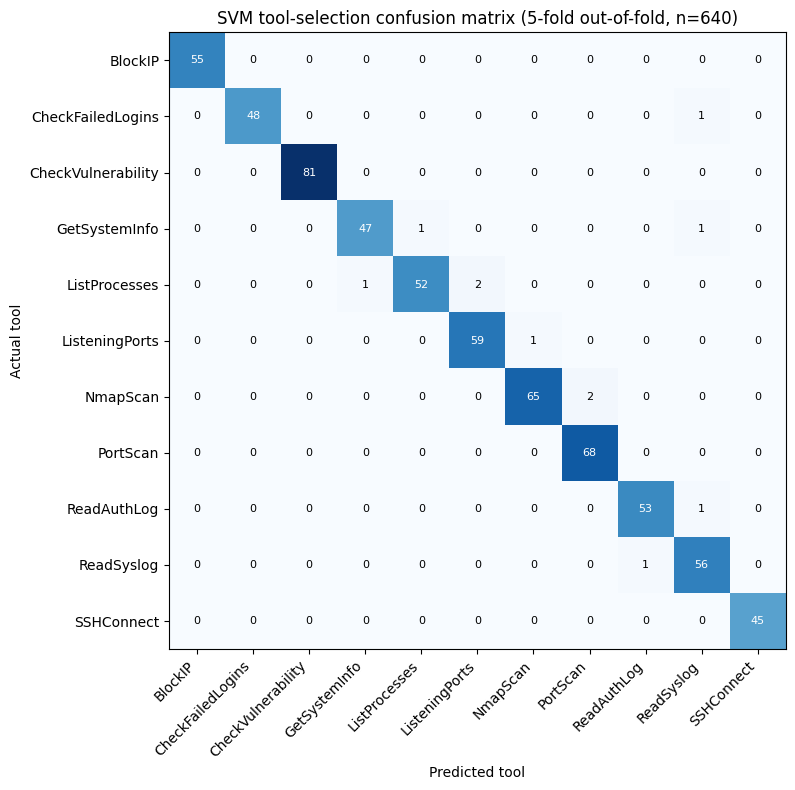

saved confusion_matrix.png


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

pred = oof["SVM"]
labels = sorted(y.unique())
print(f"SVM pooled out-of-fold accuracy: {accuracy_score(yv, pred):.1%}\n")
print(classification_report(yv, pred, zero_division=0))

cm = confusion_matrix(yv, pred, labels=labels)
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("Predicted tool"); ax.set_ylabel("Actual tool")
ax.set_title("SVM tool-selection confusion matrix (5-fold out-of-fold, n=640)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("saved confusion_matrix.png")

## 4. Classifier vs LLM

In [5]:
llm_overall = (df["tool_predicted"] == df["tool_ground_truth"]).mean()
hmask = df["difficulty"] == "hard"
llm_hard = (df.loc[hmask, "tool_predicted"] == df.loc[hmask, "tool_ground_truth"]).mean()
print(f"LLM baseline : overall {llm_overall:.1%} | hard {llm_hard:.1%}")
print(f"SVM (5-fold) : overall {rows[0]['overall_acc']} | hard {rows[0]['hard_acc']}")

LLM baseline : overall 79.4% | hard 73.5%
SVM (5-fold) : overall 98.3% +/- 0.8% | hard 94.5% +/- 2.4%


**Result.** SVM reaches ~98% overall / ~94.5% on hard queries (5-fold CV) vs
the LLM's 79.4% / 73.5% — the trained classifier beats LLM tool routing by ~19
points overall and ~21 on hard queries.